____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, 15m_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, drifters_sources, assign_attrs, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# 15m - removed limit drifter points

In [3]:
DAK = []
AK = ['swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']
for alti_key in AK:  
    f = sorted(glob(os.path.join(zarr_dir, 'save','10days_time_to_swot', f'save_savedeltaT_10days_{alti_key}*_15m.nc')))
    DAK.append(xr.open_mfdataset(f))


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_3313/1586806335.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_3313/1586806335.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_3313/1586806335.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel

## Remove drifter points at the limit 

In [11]:
rn_ok = pd.read_csv(os.path.join(zarr_dir, 'save', '10days_time_to_swot', f'10d_drifter_limit.csv'))
rn_ok = rn_ok.row_number.values
for dak in DAK :
    rn_ok = np.array(rn_ok)[np.isin(rn_ok, dak.row_number)]

DAK = [dak.sel(row_number=rn_ok) for dak in DAK]
    

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_3313/271204814.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  rn_ok = pd.read_csv(os.path.join(zarr_dir, 'save', '10days_time_to_swot', f'10d_drifter_limit.csv'))


In [14]:
D0 = []
for i in range(len(AK)):
    D = []
    for c in DAK[i].id_comb.values :
        dff = DAK[i].sel(row_number=rn_ok, id_comb=c).to_dataframe().reset_index().set_index('row_number')
        D.append(compute_mean_square_groupby(dff, groupby = 'time_to_swot_1h', compute_error = 'centrallimit'))
        print(c)
    D0.append(xr.concat(D, pd.Index([ 'LF','All', 'Inertial'], name = 'frequency_band')))
dss = xr.concat(D0, pd.Index(AK , name = 'alti_key'))


X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}

dss['sX'] = dss[X[0]]
for x in X[1:]:
    dss['sX']= dss['sX']+dss[x]

dss['time_to_swot_1h'] = (dss.time_to_swot_1h/24).assign_attrs(long_name = 'Drifter-altimetry time gap', units='day')

nofilter_LF__swot2kmnaive_etaf__rio_15era5
nofilter___swot2kmnaive_etaf__rio_15era5
nofilter_inertial__swot2kmnaive_etaf__rio_15era5
nofilter_LF__L4noswotregional_adt__rio_15era5
nofilter___L4noswotregional_adt__rio_15era5
nofilter_inertial__L4noswotregional_adt__rio_15era5
nofilter_LF__L4noswotglobal_adt__rio_15era5
nofilter___L4noswotglobal_adt__rio_15era5
nofilter_inertial__L4noswotglobal_adt__rio_15era5
nofilter_LF__L4withswot_adt__rio_15era5
nofilter___L4withswot_adt__rio_15era5
nofilter_inertial__L4withswot_adt__rio_15era5


In [15]:
dss['alti_key'] = [ 'L3-2km-SWOT','L4-regional-noSWOT','L4-global-noSWOT', 'L4-SWOT',]

In [16]:
dss['frequency_band'] = [ 'LF','All', 'Inertial']

In [17]:
dss.to_netcdf(os.path.join(zarr_dir, 'save', 'savedeltaT_all_MS_15m_removed.nc'))

___________
# If already computed 

In [6]:
dss = xr.open_dataset(os.path.join(zarr_dir, 'save', 'savedeltaT_all_MS_15m.nc'))


X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}


____
# Diag

In [18]:
def plot_error(df, x, v, ax, suf = 'ber__'):
    ax.fill_between(
        df[x], df[v] - df[suf + v], df[v] + df[suf + v], color="silver"
    )
def low_filter(ds, T=2, cutoff = [0.9], vars_ = ['B_ggd', 'E_ggd']+X):
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize

    pass_zero = True
    # coefficients
    dt = 1/24  # 1h in days
    numtaps = int(T / dt)
    pass_zero = True
    # filter
    dss = ds.fillna(0)
    taps = signal.firwin(numtaps, cutoff=cutoff, pass_zero=pass_zero, fs=1 / dt, scale=True)
    for v in vars_ : 
        dss[v] = xr.DataArray(
            filtfilt(taps, 1, dss[v]),
            dims=["alti_key", "frequency_band", "time_to_swot_1h"],
            )
    return dss
dsd = low_filter(dss, cutoff = 0.5)    


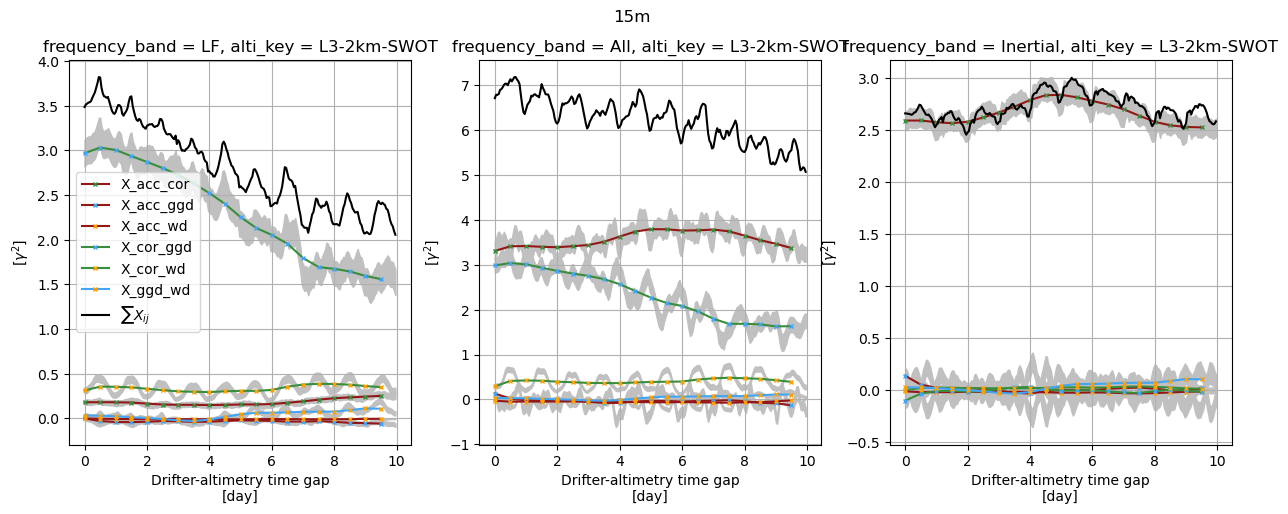

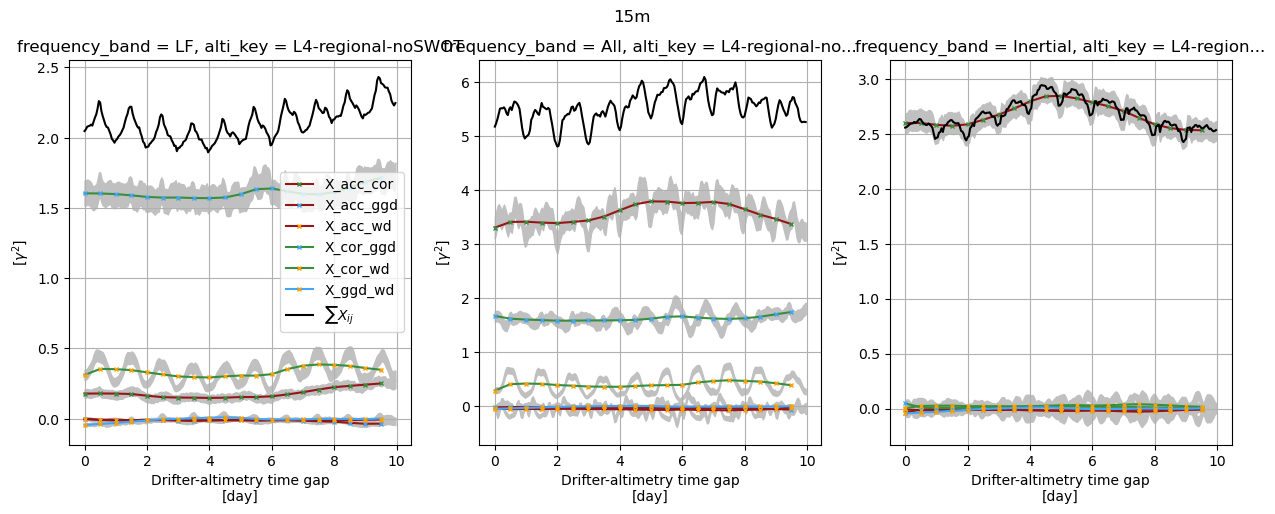

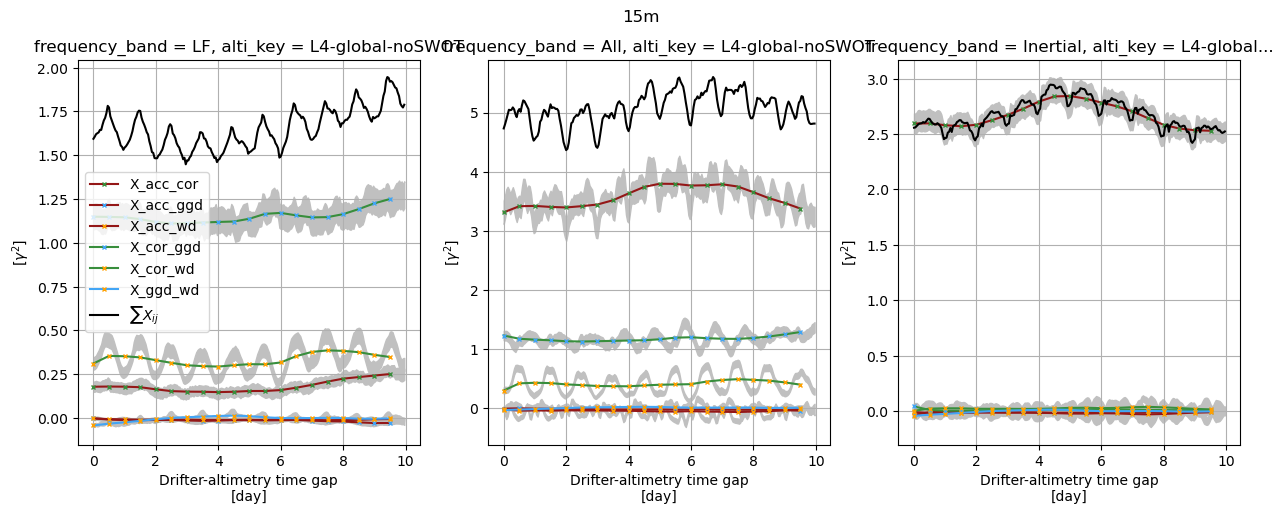

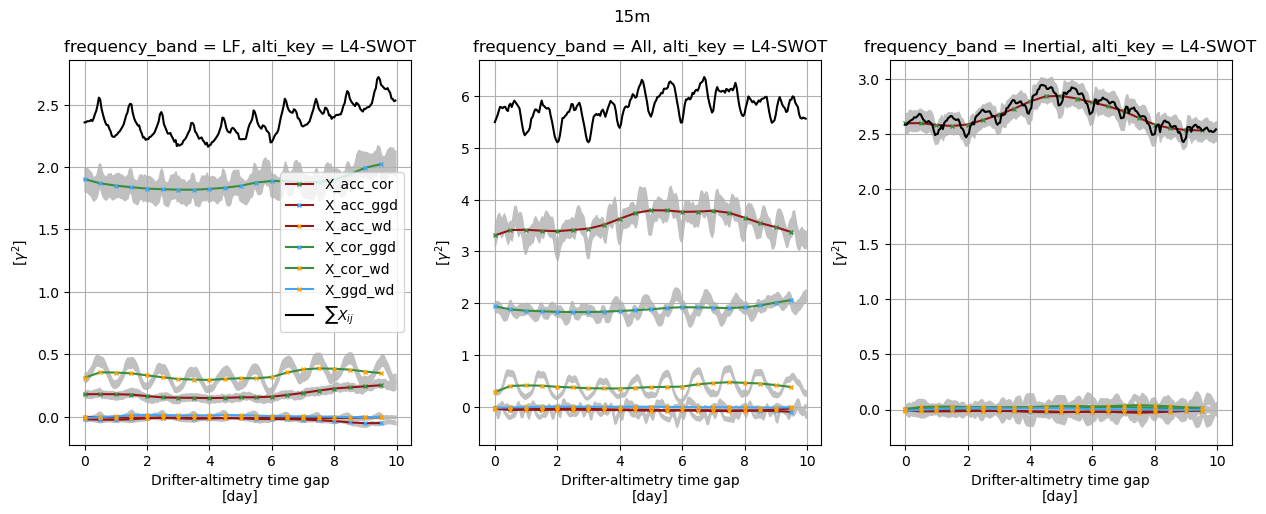

In [20]:
for al in dss.alti_key.values : 
    dss_ = dss.sel(alti_key =al)    
    dsd_ = dsd.sel(alti_key =al)
    fig, axs = plt.subplots(1, 3, figsize=(15,5), frameon=False)
    i=0
    for sp in dss.frequency_band.values : 
        ax=axs[i]
        for x in X :
            #dss_.sel(frequency_band = sp)[x].plot(label=x, **xstyle[x.replace('X_', '')], ax=ax)
            dsd_.sel(frequency_band = sp).isel(time_to_swot_1h= slice(0, None, 12))[x].plot(label=x,**xstyle[x.replace('X_', '')], ax=ax)
            plot_error(dss_.sel(frequency_band = sp),'time_to_swot_1h', x, ax, suf = 'ser__')
        ax.set_title(sp)
        
        dss_.sel(frequency_band = sp).sX.plot(c='k', label = r'$\sum X_{ij}$', ax=ax)
        i+=1
    
    axs[0].legend()
    
    for ax in axs : 
        ax.grid()
        ax.set_ylabel(r'[$\gamma^2$]')

    fig.suptitle('15m')


In [21]:
dsd_

<xarray.Dataset> Size: 774kB
Dimensions:            (frequency_band: 3, time_to_swot_1h: 240)
Coordinates:
  * time_to_swot_1h    (time_to_swot_1h) float64 2kB 0.0 0.04167 ... 9.917 9.958
  * frequency_band     (frequency_band) <U8 96B 'LF' 'All' 'Inertial'
    alti_key           <U18 72B 'L4-SWOT'
Data variables: (12/134)
    ACCe               (frequency_band, time_to_swot_1h) float64 6kB 0.04158 ...
    CORe               (frequency_band, time_to_swot_1h) float64 6kB 1.293 .....
    GGDe               (frequency_band, time_to_swot_1h) float64 6kB 0.3792 ....
    WDe                (frequency_band, time_to_swot_1h) float64 6kB 0.1044 ....
    Se                 (frequency_band, time_to_swot_1h) float64 6kB 0.8117 ....
    sigmae             (frequency_band, time_to_swot_1h) float64 6kB 1.819 .....
    ...                 ...
    ser__X_cor_ggd     (frequency_band, time_to_swot_1h) float64 6kB 0.09707 ...
    ser__X_cor_wd      (frequency_band, time_to_swot_1h) float64 6kB 0.03531 ...
    ser__X_ggd_wd      (frequency_band, time_to_swot_1h) float64 6kB 0.01036 ...
    ser__D_cyclo       (frequency_band, time_to_swot_1h) float64 6kB 0.09517 ...
    ser__D_anticyclo   (frequency_band, time_to_swot_1h) float64 6kB 0.1045 ....
    sX                 (frequency_band, time_to_swot_1h) float64 6kB 2.358 .....

Text(0.5, 0.98, '15m')

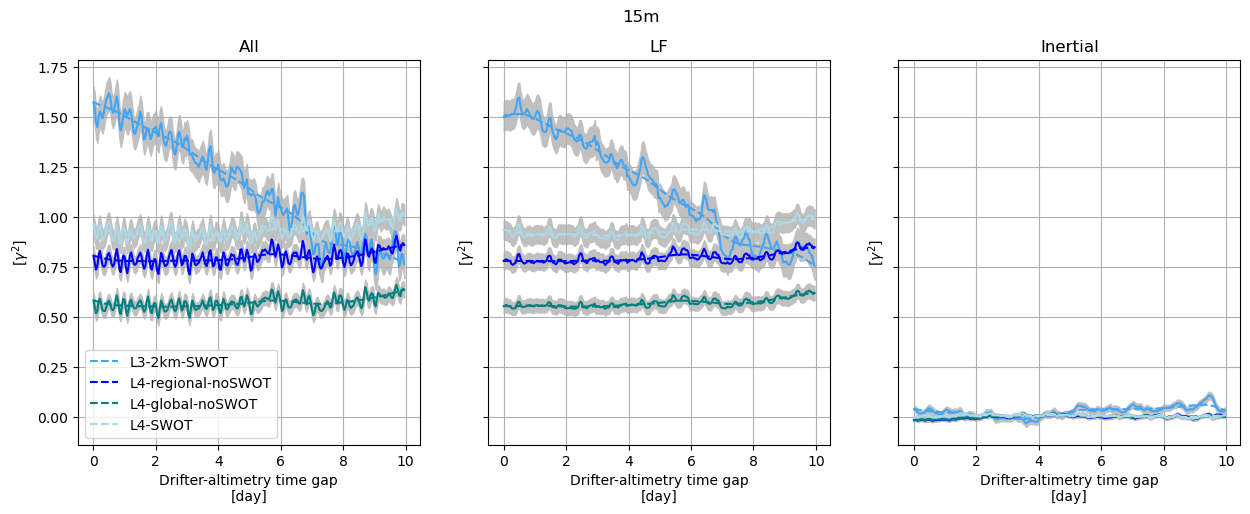

In [23]:

al_color = {'L3-250m-SWOT':'navy', 'L3-2km-SWOT':c0['ggd'],'L4-regional-noSWOT' :'b','L4-global-noSWOT':'teal', 'L4-SWOT':'lightblue'}

fig, axs = plt.subplots(1, 3, figsize=(15,5), frameon=False, sharey=True)

for al in dss.alti_key.values :
    dss_ = dss.sel(alti_key =al)    
    dsd_ = dsd.sel(alti_key =al)
    
    for v in ['ggd'] :
        dss_.sel(frequency_band = 'All')['B_'+v].plot( c = al_color[al], ax=axs[0])
        dss_.sel(frequency_band = 'LF')['B_'+v].plot( c = al_color[al], ax=axs[1])
        dss_.sel(frequency_band = 'Inertial')['B_'+v].plot( c = al_color[al], ax=axs[2])
        dsd_.sel(frequency_band = 'All')['B_'+v].plot(label=al, c = al_color[al], ls='--', ax=axs[0])
        dsd_.sel(frequency_band = 'LF')['B_'+v].plot(label=al, c = al_color[al], ls='--', ax=axs[1])
        dsd_.sel(frequency_band = 'Inertial')['B_'+v].plot( label=al, c = al_color[al], ls='--', ax=axs[2])
        plot_error(dss_.sel(frequency_band = 'All'),'time_to_swot_1h','B_'+v, axs[0], suf = 'ser__')
        plot_error(dss_.sel(frequency_band = 'LF'),'time_to_swot_1h', 'B_'+v, axs[1], suf = 'ser__')
        plot_error(dss_.sel(frequency_band = 'Inertial'),'time_to_swot_1h', 'B_'+v, axs[2], suf = 'ser__')
        
    #dss.sel(frequency_band = 'All').sX.plot(c='k', label = r'$\sum X_{ij}$', ax=axs[0])
    #dss.sel(frequency_band = 'LF').sX.plot(c='k', ax=axs[1])
    #dss.sel(frequency_band = 'Inertial').sX.plot(c='k', ax=axs[2])
    
axs[0].legend()

axs[0].set_title('All')
axs[1].set_title('LF')
axs[2].set_title('Inertial')

for ax in axs : 
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    #ax.set_xlabel('Drifter-altimetry time gap [h]')

fig.suptitle('15m')


In [24]:
al_color = {'L3-250m-SWOT':'navy', 'L3-2km-SWOT':c0['ggd'],'L4-regional-noSWOT' :'b','L4-global-noSWOT':'teal', 'L4-SWOT':'light_blue'}

In [25]:
dss = dss.rename_dims({'time_to_swot_1h':'time'})
dss['time'] = dss['time_to_swot_1h'] * pd.Timedelta('1d')
dssf = dss.drop('time_to_swot_1h')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_3313/2060404584.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  dssf = dss.drop('time_to_swot_1h')


In [26]:
dssf = dss.drop('time_to_swot_1h')
dssf

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_3313/1548404067.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  dssf = dss.drop('time_to_swot_1h')


<xarray.Dataset> Size: 3MB
Dimensions:            (alti_key: 4, frequency_band: 3, time: 240)
Coordinates:
  * frequency_band     (frequency_band) <U8 96B 'LF' 'All' 'Inertial'
  * alti_key           (alti_key) <U18 288B 'L3-2km-SWOT' ... 'L4-SWOT'
  * time               (time) timedelta64[ns] 2kB 00:00:00 ... 9 days 23:00:00
Data variables: (12/134)
    ACCe               (alti_key, frequency_band, time) float64 23kB 0.04158 ...
    CORe               (alti_key, frequency_band, time) float64 23kB 1.293 .....
    GGDe               (alti_key, frequency_band, time) float64 23kB 1.101 .....
    WDe                (alti_key, frequency_band, time) float64 23kB 0.1044 ....
    Se                 (alti_key, frequency_band, time) float64 23kB 1.187 .....
    sigmae             (alti_key, frequency_band, time) float64 23kB 2.54 ......
    ...                 ...
    ser__X_cor_ggd     (alti_key, frequency_band, time) float64 23kB 0.1468 ....
    ser__X_cor_wd      (alti_key, frequency_band, time) float64 23kB 0.03531 ...
    ser__X_ggd_wd      (alti_key, frequency_band, time) float64 23kB 0.01966 ...
    ser__D_cyclo       (alti_key, frequency_band, time) float64 23kB 0.1472 ....
    ser__D_anticyclo   (alti_key, frequency_band, time) float64 23kB 0.1534 ....
    sX                 (alti_key, frequency_band, time) float64 23kB 3.486 .....

In [30]:
from sstats import tseries as ts
rename_forspectra = {'datetime':'time', 'drifter_id':'id'}
def spectrum_ds(ds, nperseg="10D", detrend=False, vc = [ ('B_ggd', 'B_ggd')]):
    #ds = df.reset_index().set_index(["time", "id"]).to_xarray()
    E = []
    for tup in vc:
        ds_ = ds.fillna(0).ts.spectrum(unit="1D", nperseg=nperseg, detrend=detrend, complex=tup)
        E.append(ds_)
    return xr.merge(E)

dsp = spectrum_ds(dssf.fillna(0), nperseg="10D", detrend=False)
dsp

<xarray.Dataset> Size: 25kB
Dimensions:         (frequency_band: 3, alti_key: 4, frequency: 240)
Coordinates:
  * frequency_band  (frequency_band) <U8 96B 'LF' 'All' 'Inertial'
  * alti_key        (alti_key) <U18 288B 'L3-2km-SWOT' ... 'L4-SWOT'
  * frequency       (frequency) float64 2kB -12.0 -11.9 -11.8 ... 11.7 11.8 11.9
Data variables:
    B_ggd_B_ggd     (alti_key, frequency_band, frequency) float64 23kB 1.978e...

In [31]:
def negpos_spectra(ds, freqkey="frequency"):
    """Return two datasets with cyclonic/anticyclonic spectra"""
    ds_inv = ds.sortby(freqkey, ascending=False)
    dsneg = ds_inv.where(ds_inv[freqkey] <= 0, drop=True)
    dsneg[freqkey] = -dsneg[freqkey]
    dspos = ds.where(ds[freqkey] >= 0, drop=True)
    return dsneg, dspos

dsnp = sum(negpos_spectra(dsp, freqkey="frequency"))


<xarray.Dataset> Size: 13kB
Dimensions:         (frequency_band: 3, alti_key: 4, frequency: 120)
Coordinates:
  * frequency_band  (frequency_band) <U8 96B 'LF' 'All' 'Inertial'
  * alti_key        (alti_key) <U18 288B 'L3-2km-SWOT' ... 'L4-SWOT'
  * frequency       (frequency) float64 960B -0.0 0.1 0.2 0.3 ... 11.7 11.8 11.9
Data variables:
    B_ggd_B_ggd     (alti_key, frequency_band, frequency) float64 12kB 34.36 ...

1.2890950082486392


Text(0.5, 1.0, '')

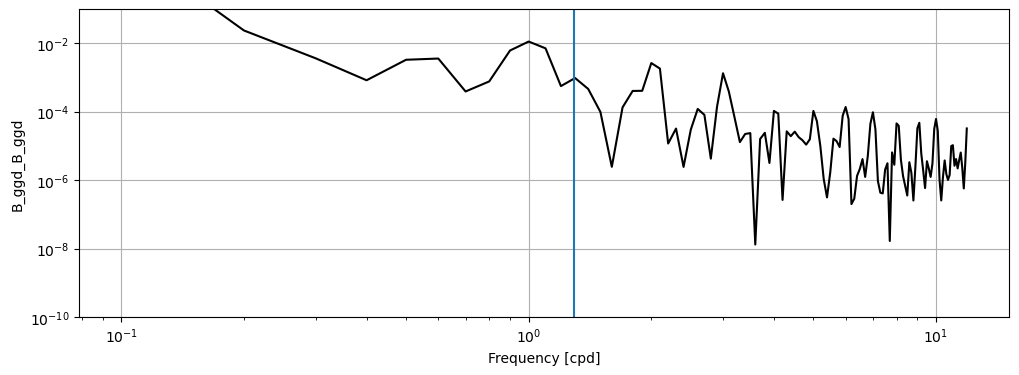

In [32]:
linthresh = 1e-1
linscale = 0.3
fig, ax = plt.subplots(1, 1, figsize=(12, 4), frameon=False)
fc = pyn.geo.coriolis(40) * 86400 / 2 / np.pi
print(fc)

dsnp.sel(frequency_band='LF').sel(alti_key = 'L3-2km-SWOT').B_ggd_B_ggd.plot(ax=ax,label = 'LF', c='k')
ax.axvline(abs(fc))
ax.set_xlabel("Frequency [cpd]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid()
ax.set_ylim(1e-10, 1e-1)
#ax.set_xlim(-24 * 60 / 30 / 2, 24 * 60 / 30 / 2)
ax.set_title("")

In [35]:
def low_filter(ds, T=1, cutoff = [0.9], vars_ = ['B_ggd', 'E_ggd']+X):
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize

    pass_zero = True
    # coefficients
    dt = 1/24  # 1h in days
    numtaps = int(T / dt)
    pass_zero = True
    # filter
    dss = ds.fillna(0)
    taps = signal.firwin(numtaps, cutoff=cutoff, pass_zero=pass_zero, fs=1 / dt, scale=True)
    for v in vars_ : 
        ds[v] = xr.DataArray(
            filtfilt(taps, 1, ds[v]),
            dims=["alti_key","frequency_band", "time"],
            )
    return ds
dsd = low_filter(dssf, T=1, cutoff = 0.5, vars_ = ['B_ggd'])    

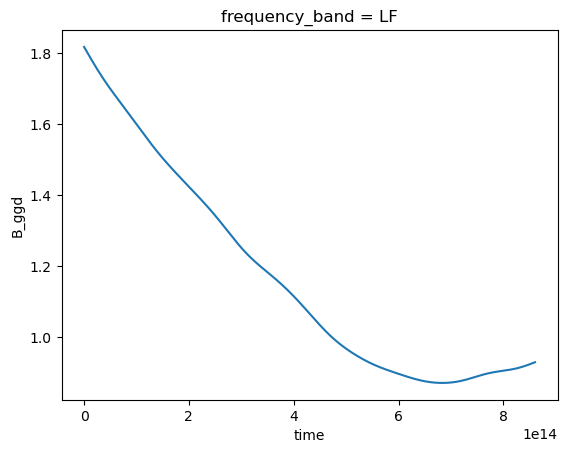

In [61]:
dsd.sel(frequency_band = 'LF')['B_ggd'].plot()

In [ ]:
def filter_traj(ds, T=10, cutoff = { 'HF':[2.2, 70.95], 'LF': [0.88],'inertial':[1.05, 1.75], 'diurnal' : [0.88, 1.05], 'semidiurnal':[1.9, 2.1],}):
    """Return dataset with filtered trajectories acceleration and coriolis term (inertial, diurnal, semidiurnal)
    T: window length days
    """
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize
    
    # coefficients
    dt = 1/24/6  # 10min in days
    numtaps = int(T / dt)
    pass_zero = False


    # filter
    dss = ds.fillna(0)
    for c in cutoff : 
        if c == 'LF' : pass_zero = True
        #elif c == 'HF' : pass_zero = 'highpass'
        else : pass_zero = False
 
        taps = signal.firwin(numtaps, cutoff=cutoff[c], pass_zero=pass_zero, fs=1 / dt, scale=True)
        dss[c+'_velocity_east'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_east),
            dims=["drifter_id", "datetime"],
            )
        dss[c+'_velocity_north'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_north),
            dims=["drifter_id","datetime"],
            )
        dss[c+'_acceleration_east'] = (
            (dss[c+'_velocity_east'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_east.attrs)
        )
        dss[c+'_acceleration_north'] = (
            (dss[c+'_velocity_north'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_north.attrs)
        )
        print(c)
    
    return dss

In [17]:
import xrscipy.signal as dsp

dsp.spectrogram(dss.B_ggd, dim='time_to_swot_1h')

ModuleNotFoundError: No module named 'xrscipy'

In [30]:
dss = dss.drop('time')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_8399/3230689681.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  dss = dss.drop('time')


In [31]:
dss

<xarray.Dataset> Size: 776kB
Dimensions:            (frequency_band: 3, time_to_swot_1h: 240)
Coordinates:
  * time_to_swot_1h    (time_to_swot_1h) float64 2kB 0.0 0.04167 ... 9.917 9.958
  * frequency_band     (frequency_band) object 24B 'LF' 'Inertial' 'All'
Data variables: (12/135)
    ACCe               (frequency_band, time_to_swot_1h) float64 6kB 0.08699 ...
    CORe               (frequency_band, time_to_swot_1h) float64 6kB 2.177 .....
    GGDe               (frequency_band, time_to_swot_1h) float64 6kB 1.174 .....
    WDe                (frequency_band, time_to_swot_1h) float64 6kB 0.7957 ....
    Se                 (frequency_band, time_to_swot_1h) float64 6kB 1.353 .....
    sigmae             (frequency_band, time_to_swot_1h) float64 6kB 4.234 .....
    ...                 ...
    ser__X_cor_wd      (frequency_band, time_to_swot_1h) float64 6kB 0.1094 ....
    ser__X_ggd_wd      (frequency_band, time_to_swot_1h) float64 6kB 0.03617 ...
    ser__D_cyclo       (frequency_band, time_to_swot_1h) float64 6kB 0.1122 ....
    ser__D_anticyclo   (frequency_band, time_to_swot_1h) float64 6kB 0.1386 ....
    sX                 (frequency_band, time_to_swot_1h) float64 6kB 5.853 .....
    datetime           (time_to_swot_1h) timedelta64[ns] 2kB 00:00:00 ... 9 d...

In [51]:
dsp

<xarray.Dataset> Size: 2kB
Dimensions:         (frequency_band: 3, frequency: 48)
Coordinates:
  * frequency_band  (frequency_band) object 24B 'LF' 'Inertial' 'All'
  * frequency       (frequency) float64 384B -12.0 -11.5 -11.0 ... 11.0 11.5
Data variables:
    Be_ggd_Bn_ggd   (frequency_band, frequency) float64 1kB 1.492e-06 ... 2.2...